# Exploración y Preprocesamiento de Datos

En este notebook se realiza el análisis exploratorio y el preprocesamiento del conjunto de datos **CICIDS-2017**, con el objetivo de obtener un conjunto de datos limpio y preparado para aplicar algoritmos de RandomForest y MLP.

Las etapas incluyen la inspección inicial del dataset, el análisis de calidad de los datos, la exploración de las variables y el preprocesamiento necesario para el modelado.

In [2]:
#Importación de librerías
import numpy as np
import pandas as pd
import os
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

plt.style.use("default")
sns.set_theme(style="whitegrid")

warnings.filterwarnings('ignore')

pd.set_option("display.max_columns", None)

---
## Carga del conjunto de datos

Se carga el dataset y se realiza una primera inspección para conocer su estructura.

In [3]:
df1 = pd.read_csv("../datos/raw/Monday-WorkingHours.pcap_ISCX.csv")
df2 = pd.read_csv("../datos/raw/Tuesday-WorkingHours.pcap_ISCX.csv")
df3 = pd.read_csv("../datos/raw/Wednesday-workingHours.pcap_ISCX.csv")
df4 = pd.read_csv("../datos/raw/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv")
df5 = pd.read_csv("../datos/raw/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv")
df6 = pd.read_csv("../datos/raw/Friday-WorkingHours-Morning.pcap_ISCX.csv")
df7 = pd.read_csv("../datos/raw/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
df8 = pd.read_csv("../datos/raw/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv")

In [4]:
df = pd.concat([df1, df2, df3, df4, df5, df6, df7, df8], ignore_index=True)

df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,3000000.0,5.000000e+05,4.0,0.0,4,4,4,4.0,0.0,4,4,0,0.0,0.0,0,0,0,0,0,0,40,0,5.000000e+05,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4000000.0,6.666667e+05,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,6.666667e+05,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,245,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [5]:
print(f"Número de observaciones: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

df.info()

Número de observaciones: 2830743
Número de variables: 79
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IA

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0,NaN,NaN,NaN,8071.482501,18283.632172,0.0,53.0,80.0,443.0,65535.0
Flow Duration,2830743.0,NaN,NaN,NaN,14785663.929522,33653744.085855,-13.0,155.0,31316.0,3204828.5,119999998.0
Total Fwd Packets,2830743.0,NaN,NaN,NaN,9.36116,749.672792,1.0,2.0,2.0,5.0,219759.0
Total Backward Packets,2830743.0,NaN,NaN,NaN,10.39377,997.388269,0.0,1.0,2.0,4.0,291922.0
Total Length of Fwd Packets,2830743.0,NaN,NaN,NaN,549.302415,9993.589229,0.0,12.0,62.0,187.0,12900000.0
...,...,...,...,...,...,...,...,...,...,...,...
Idle Mean,2830743.0,NaN,NaN,NaN,8316036.627208,23630078.577951,0.0,0.0,0.0,0.0,120000000.0
Idle Std,2830743.0,NaN,NaN,NaN,503843.949779,4602984.480672,0.0,0.0,0.0,0.0,76900000.0
Idle Max,2830743.0,NaN,NaN,NaN,8695751.984586,24366888.329043,0.0,0.0,0.0,0.0,120000000.0
Idle Min,2830743.0,NaN,NaN,NaN,7920031.014637,23363418.927478,0.0,0.0,0.0,0.0,120000000.0


---
## Calidad de los datos

Antes de comenzar el análisis se verifica la existencia de valores faltantes y registros duplicados.

In [7]:
#Busqueda de duplicados
df.duplicated().sum()

np.int64(308381)

In [8]:
#Eliminacion de duplicados
df.drop_duplicates(inplace=True)

In [9]:
#Busqueda de faltantes
df.isna().sum().sum()

np.int64(353)

In [10]:
#Tratamineto de faltantes numericas
df = df.fillna(df.mean(numeric_only=True))

In [11]:
#verificacion de faltantes no numericas
df.isna().sum().sum()

np.int64(0)

In [12]:
#Busqueda y tratamiento de valores infinitos
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())
df = df.replace([np.inf, -np.inf], np.nan).dropna()

3128


Se buscaron valores faltantes, duplicados e infinitos. 

- Valores duplicados: Se reportaron 308381 valores duplicados. Se decidió eliminar esos datos para evitar posibles malas lecturas.
- Valores faltantes: se reportaron 353 valores faltantes. Decidi reemplazar los valores por la respectiva media. Se usó este método porque es simple y efectiva para valores numericos. Además, lo elegi antes de quitar los datos, para evitar desechar datos que podrian ser importantes.
- Valores infinitos: Se reportaron 3128 valores infinitos positivos o negativos. Las filas fueron quitadas para evitar errores, ya que no todos los modelos de machine learning funcionan correctamente con datos infinitos.


---
## Consolidacion de etiquetas

In [13]:
#Categorias
df[' Label'].value_counts()

 Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [14]:
#Recategorizacion
def consolidar_label(label):
    if label == 'BENIGN':
        return 'BENIGN'
    elif label in ['DoS Hulk', 'DoS GoldenEye', 'DoS slowloris', 'DoS Slowhttptest']:
        return 'DoS'
    elif label in ['DDoS']:
        return 'DDoS'
    elif 'Web Attack' in label:
        return 'Web Attack'
    elif label == 'PortScan':
        return 'PortScan'
    elif label == 'Bot':
        return 'Bot'
    else:
        return 'Other'
df[' Label'] = df[' Label'].apply(consolidar_label)


In [15]:
#Verificacion
df[' Label'].value_counts()

 Label
BENIGN        2095057
DoS            193745
DDoS           128014
PortScan        90694
Other            9197
Web Attack       2143
Bot              1948
Name: count, dtype: int64

Se comprobaron las etiquetas de la columna 'Label'. Se detectaron 15 variables variables distintas, las cuales fueron agrupadas para reducir la complejidad del modelo. Las agrupaciones fueron:

- Benign: Los benign que son los trafico normal no se tocaron ni se agruparon.
- DoS: Todas las denegaciones de servicio de distinto origen fueron juntadas en una sola categoría incluyente.
- PortScan: Son ataques de reconocimiento. No se agruparon ni modificaron.
- DDoS: Las denegaciones de servicio de origen múltiple se dejaron en la misma variable
- Web atack: Los ataques a aplicaciones web fueron consolidadas en una sola variable.
- Other: Se juntaron las demás categorias restantes.

Con esta agrupacion, se divide entre trafico normal, y los principales tipos de ataques.

---
## Partición y escalado de datos

In [16]:
# Separar variables predictoras y variable objetivo
X = df.drop(columns=" Label")
y = df[" Label"]

# Separar en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [17]:
scaler = StandardScaler()

# Ajuste del scaler de train
X_train_scaled = scaler.fit_transform(X_train)

# Transformacion a test
X_test_scaled = scaler.transform(X_test)

In [18]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

Se separaron las variables predictoras (X) de la variable objetivo (y), que corresponde a las siete clases de tráfico de red definidas anteriormente.

Luego, el conjunto de datos se particiono en train, para el posterior entrenamiento de los modelos, y test, para la evaluacion del desempeño final. La particion fue 80% de los datos para train, y 20% para test. La particion fue estratificada, con el objetivo de mantener la misma proporcion de clases de la variable Y en ambos conjuntos. Esto se debio a que debido a la predominancia de la clase 'Benign', podrian quedar clases fuera de algun conjunto. 

Por ultimo, se aplico estandarizacion unicamente al conjunto de entrenamiento, para hacer que los modelos sean menos sensible a escalas. Una vez ajustado el escalador, se aplico la misma transformacion al conjunto de entrenamiento tanto al conjunto de entrenamiento como al conjunto de prueba. La diferencia es que el conjunto train calcula los parametros, y luego transforma, mientras que en test se aplica la transformacion con los parametros obtenidos a partir de train, evitando asi "ver" el conjunto de test previo al modelado.

---
## Correlacion de variables

In [19]:
# Matriz de correlación de las variables predictoras
corr_matrix = X_train_scaled.corr().abs()

corr_matrix

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Destination Port,1.000000,0.171645,0.004580,0.004305,0.009104,0.003408,0.091686,0.046507,0.137589,0.123589,0.212409,0.262433,0.238573,0.190239,0.070672,0.359761,0.113512,0.131720,0.130668,0.023454,0.170826,0.106908,0.110907,0.129411,0.055355,0.119759,0.075752,0.041703,0.061566,0.054944,0.235041,NaN,0.004569,NaN,0.000495,0.000727,0.348838,0.144452,0.254411,0.143052,0.170993,0.139074,0.077199,0.037750,0.235041,0.007166,0.217267,0.584694,0.523890,0.004569,0.007055,0.027366,0.172458,0.137589,0.238573,0.000495,NaN,NaN,NaN,NaN,NaN,NaN,0.004580,0.009119,0.004305,0.003408,0.132996,0.206332,0.003511,0.001003,0.041064,0.048303,0.058339,0.027369,0.127753,0.006656,0.123464,0.129285
Flow Duration,0.171645,1.000000,0.020996,0.019901,0.060434,0.016745,0.263705,0.115649,0.133976,0.225046,0.486006,0.239143,0.448487,0.433693,0.025086,0.109883,0.534577,0.734780,0.779810,0.060544,0.998543,0.543293,0.721030,0.779562,0.209292,0.820266,0.408894,0.518243,0.580678,0.212530,0.017050,NaN,0.002673,NaN,0.000101,0.001197,0.099457,0.080583,0.247113,0.501656,0.417413,0.445277,0.272017,0.218805,0.017050,0.008488,0.180347,0.032978,0.117353,0.002673,0.008423,0.164797,0.395011,0.133976,0.448487,0.000101,NaN,NaN,NaN,NaN,NaN,NaN,0.020996,0.060521,0.019901,0.016744,0.094274,0.034322,0.016257,0.001304,0.187509,0.239079,0.291521,0.118691,0.764003,0.240299,0.775633,0.733986
Total Fwd Packets,0.004580,0.020996,1.000000,0.999102,0.367013,0.997212,0.008732,0.003197,0.000412,0.000906,0.022654,0.005970,0.021331,0.005936,0.000435,0.002302,0.001437,0.001092,0.001569,0.000582,0.020710,0.001423,0.000502,0.001179,0.001269,0.024363,0.000935,0.000314,0.002754,0.001130,0.002237,NaN,0.000059,NaN,0.000434,0.014776,0.002099,0.001617,0.006671,0.021799,0.024452,0.011647,0.005160,0.001343,0.002237,0.000350,0.006529,0.001804,0.003723,0.000059,0.000348,0.001070,0.022061,0.000412,0.021331,0.000434,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.367549,0.999102,0.997208,0.003312,0.000661,0.887377,0.000201,0.024771,0.007624,0.020358,0.024543,0.001079,0.000575,0.001154,0.000959
Total Backward Packets,0.004305,0.019901,0.999102,1.000000,0.361107,0.994465,0.008451,0.002809,0.000744,0.000567,0.022438,0.005294,0.021439,0.005624,0.000381,0.002342,0.001761,0.001532,0.001138,0.000606,0.019598,0.001592,0.000992,0.000737,0.001148,0.023833,0.001082,0.000125,0.002822,0.001091,0.002036,NaN,0.000060,NaN,0.000727,0.014792,0.002192,0.001350,0.006083,0.021532,0.024833,0.011503,0.005116,0.001199,0.002036,0.000228,0.005998,0.001642,0.003124,0.000060,0.000226,0.003304,0.022452,0.000744,0.021439,0.000727,NaN,NaN,NaN,NaN,NaN,NaN,0.999102,0.361643,1.000000,0.994462,0.002788,0.000666,0.883164,0.000022,0.023836,0.005852,0.018601,0.024529,0.000717,0.

In [20]:
# Seleccionamos solamente la parte superior de la matriz
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Variables que tienen al menos una correlación > 0.85
to_drop = [
    column for column in upper.columns
    if any(upper[column] > 0.85)
]

print("Cantidad de variables a eliminar:", len(to_drop))
print("Variables a eliminar:")
print(to_drop)

Cantidad de variables a eliminar: 34
Variables a eliminar:
[' Total Backward Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', ' Flow IAT Max', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', ' Bwd IAT Min', 'Fwd Packets/s', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', ' SYN Flag Count', ' CWE Flag Count', ' ECE Flag Count', ' Average Packet Size', ' Avg Fwd Segment Size', ' Avg Bwd Segment Size', ' Fwd Header Length.1', 'Subflow Fwd Packets', ' Subflow Fwd Bytes', ' Subflow Bwd Packets', ' Subflow Bwd Bytes', ' act_data_pkt_fwd', ' Active Min', 'Idle Mean', ' Idle Max', ' Idle Min']


In [21]:
X_train_scaled = X_train_scaled.drop(columns=to_drop)
X_test_scaled = X_test_scaled.drop(columns=to_drop)

In [22]:
print("Variables antes:", corr_matrix.shape[0])
print("Variables después:", X_train_scaled.shape[1])

Variables antes: 78
Variables después: 44


Se realizó el analisis de correlación entre las variables del conjunto de entrenamiento unicamente, con el objetivo de identificar aquellas variables que contienen información muy similar. 

Para ello, se realizó la matriz de correlación, la cual calcula el valor absoluto del coeficiente de correlación de Pearson entre cada par de variables. Aquellas variables que presentan una corelación mayor a 0,85 se considera que tienen una correlación elevada. En estos caso, se elimina una de las variables para reducir redundancia.

---
## Balanceo de clases mediante SMOTE

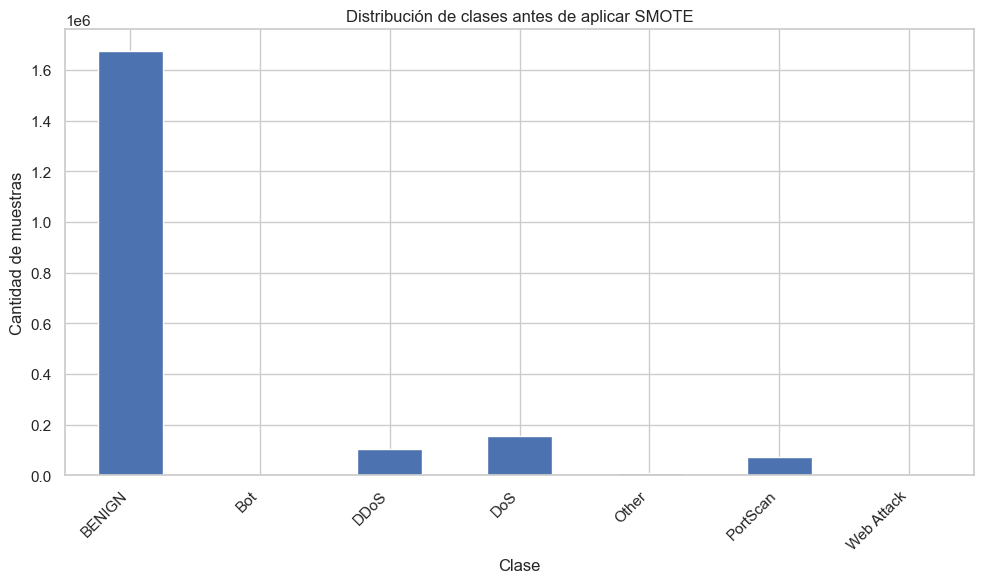

In [ ]:
# Cantidad de ejemplos por clase
conteo_clases = y_train.value_counts().sort_index()

plt.figure(figsize=(10, 6))
conteo_clases.plot(kind='bar')

plt.title("Distribución de clases antes de aplicar SMOTE")
plt.xlabel("Clase")
plt.ylabel("Cantidad de muestras")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [23]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [24]:
print("Antes de SMOTE:")
print(y_train.value_counts())

print("\nDespués de SMOTE:")
print(y_train_smote.value_counts())

Antes de SMOTE:
 Label
BENIGN        1676045
DoS            154996
DDoS           102411
PortScan        72555
Other            7358
Web Attack       1714
Bot              1559
Name: count, dtype: int64

Después de SMOTE:
 Label
BENIGN        1676045
DoS           1676045
PortScan      1676045
DDoS          1676045
Other         1676045
Web Attack    1676045
Bot           1676045
Name: count, dtype: int64


El dataset presenta un importante desbalance entre las clases, ya que hay una fuerte predominancia de la clase benign por sobre las demas. Este desbalance podria afectar el entrenamiento de los modelos, por lo que se opto por la aplicacion de SMOTE (Synthetic Over-Sampling Technique). Esto genera nuevas observaciones sinteticas de las clases minoritarias a partir de las ya existentes, con el objetivo de aumentar su representacion en el conjunto de entrenamiento. 

Esta técnica se aplicó solo al conjunto de entrenamiento, ya que el conjunto de prueba debe preservar la distribución original de los datos.

El resultado de esto es un conjunto de entrenamiento limpio, estandarizado, no redundante y balanceado, listo para la aplicación de modelados, y un conjunto de prueba intacto.

---
## Exportacion de los datos procesados

In [25]:
#Creacion carpeta para los datos procesados
os.makedirs("../datos/processed", exist_ok=True)

# Exportar los conjuntos
X_train_smote.to_csv("../datos/processed/X_train.csv", index=False)

X_test_scaled.to_csv("../datos/processed/X_test.csv", index=False)

y_train_smote.to_csv("../datos/processed/y_train.csv", index=False)

y_test.to_csv("../datos/processed/y_test.csv", index=False)

print("Archivos exportados correctamente.")

Archivos exportados correctamente.
